# Title

## Module Imports

In [46]:
from dataclasses import dataclass
from typing import Callable
import pickle
import mlflow
import nico2_lib as n2l
import matplotlib.pyplot as plt
import numpy as np
from numpy import number
from numpy.typing import NDArray
import polars as pl
import seaborn as sns
from experiment import (
    ExperimentOutput,
    CelltypeMetadata,
    SplitResult,
    ModelSplitResult,
    CelltypeSplitResult,
)

In [68]:
MetricFn = Callable[[NDArray[number], NDArray[number]], float]


def build_reconstruction_metric_registry() -> dict[str, MetricFn]:
    return {"pearsonr": n2l.mt.pearson_metric, "spearmanr": n2l.mt.spearman_metric}


def _score_celltype(
    metric: MetricFn, observed: np.ndarray, predicted: np.ndarray
) -> float:
    return float(
        np.nan_to_num(
            np.array(
                [
                    metric(observed_cell, predicted_cell)
                    for observed_cell, predicted_cell in zip(observed, predicted)
                ]
            )
        ).mean()
    )

In [260]:
benchmark_experiment = mlflow.get_experiment_by_name("Default")
runs = mlflow.search_runs(experiment_ids=[benchmark_experiment.experiment_id])
last_run_id = runs.sort_values("start_time", ascending=False)["run_id"].iloc[0]

In [262]:
runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,params.n_pca_components,params.n_samples,params.cache_dir,params.dataloader_keys,params.predictor_keys,params.seed,params.data_dir,params.sample_length,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.type
0,e3357789bc4e4b98b8c3f6c2ce0182c1,0,FINISHED,/Users/egerc/Documents/Projects/notebook_repos...,2026-02-20 12:28:11.819000+00:00,2026-02-20 12:28:20.931000+00:00,10,10,../cache,['small_mouse_intestine_spatial'],"['NMF_3', 'NMF_8']",0,../data,20,experiment.py,f609e47d2d869dd72a75a142382d17af98608819,luminous-pug-166,egerc,LOCAL
1,4503cec65cbe43e98a15188bac845c25,0,FINISHED,/Users/egerc/Documents/Projects/notebook_repos...,2026-02-20 11:32:31.465000+00:00,2026-02-20 11:32:40.858000+00:00,25,10,../cache,['small_mouse_intestine_spatial'],"['NMF_3', 'NMF_8']",0,../data,20,experiment.py,f609e47d2d869dd72a75a142382d17af98608819,treasured-cow-4,egerc,LOCAL
2,ab49985ef55c4706b6d12413d52e9212,0,FINISHED,/Users/egerc/Documents/Projects/notebook_repos...,2026-02-20 10:59:33.911000+00:00,2026-02-20 10:59:43.737000+00:00,25,10,../cache,['small_mouse_intestine_spatial'],"['NMF_3', 'NMF_8']",0,../data,20,experiment.py,f609e47d2d869dd72a75a142382d17af98608819,omniscient-cod-734,egerc,LOCAL
3,117782d4562a417ea8e80a1301d90e69,0,FINISHED,/Users/egerc/Documents/Projects/notebook_repos...,2026-02-20 10:44:58.097000+00:00,2026-02-20 10:45:08.082000+00:00,25,10,../cache,['small_mouse_intestine_spatial'],"['NMF_3', 'NMF_8']",0,../data,20,experiment.py,f609e47d2d869dd72a75a142382d17af98608819,rogue-crab-626,egerc,LOCAL
4,5f060bcc4e8c444fa138cbcaa870af7c,0,FINISHED,/Users/egerc/Documents/Projects/notebook_repos...,2026-02-20 10:07:02.603000+00:00,2026-02-20 10:07:12.565000+00:00,25,10,../cache,['small_mouse_intestine_spatial'],"['NMF_3', 'NMF_8']",0,../data,20,experiment.py,f609e47d2d869dd72a75a142382d17af98608819,abundant-hound-212,egerc,LOCAL
5,ca8af6c4a03f4323a78cfc95f474c07a,0,FINISHED,/Users/egerc/Documents/Projects/notebook_repos...,2026-02-20 09:28:47.362000+00:00,2026-02-20 09:28:58.236000+00:00,25,10,../cache,['small_mouse_intestine_spatial'],"['NMF_3', 'NMF_8']",0,../data,20,experiment.py,f609e47d2d869dd72a75a142382d17af98608819,youthful-chimp-805,egerc,LOCAL
6,9a80e2c1ab3543c4a3219e68afd7a3cc,0,FINISHED,/Users/egerc/Documents/Projects/notebook_repos...,2026-02-19 16:07:39.844000+00:00,2026-02-19 16:07:50.626000+00:00,25,10,../cache,None,None,0,../data,20,experiment.py,e981dd74cd5a7049d1eb276f5fc78ad72d1f882a,indecisive-fish-799,egerc,LOCAL


In [261]:
artifact_path = mlflow.artifacts.download_artifacts(
    run_id=last_run_id, artifact_path="results.pkl"
)
with open(artifact_path, "rb") as f:
    results = pickle.load(f)

In [69]:
reconstruction_metrics = build_reconstruction_metric_registry()
rows: list[dict[str, object]] = []

for experiment_output in results:
    for split_result in experiment_output.split_results:
        for model_result in split_result.model_results:
            for prediction_scope in ("global", "celltype"):
                for metric_name, metric in reconstruction_metrics.items():
                    celltype_scores: list[float] = []
                    celltype_weights: list[int] = []

                    for celltype_result in model_result.celltype_results:
                        observed = np.asarray(celltype_result.observed_test_counts)
                        predicted = np.asarray(
                            celltype_result.global_model_predicted_test_counts
                            if prediction_scope == "global"
                            else celltype_result.celltype_model_predicted_test_counts
                        )
                        celltype_scores.append(
                            _score_celltype(metric, observed, predicted)
                        )
                        celltype_weights.append(celltype_result.n_cells)

                    if not celltype_scores:
                        continue

                    scores = np.asarray(celltype_scores, dtype=float)
                    weights = np.asarray(celltype_weights, dtype=float)
                    aggregations = {
                        "macro": float(scores.mean()),
                        "weighted": float(np.average(scores, weights=weights)),
                    }
                    for aggregation, score in aggregations.items():
                        rows.append(
                            {
                                "dataset_name": experiment_output.dataset_name,
                                "model_name": model_result.model_name,
                                "prediction_scope": prediction_scope,
                                "sample_idx": split_result.sample_idx,
                                "metric_name": metric_name,
                                "aggregation": aggregation,
                                "score": score,
                                "n_celltypes": int(scores.size),
                                "total_cells": int(weights.sum()),
                            }
                        )

df_prediction_scores = pl.DataFrame(rows)

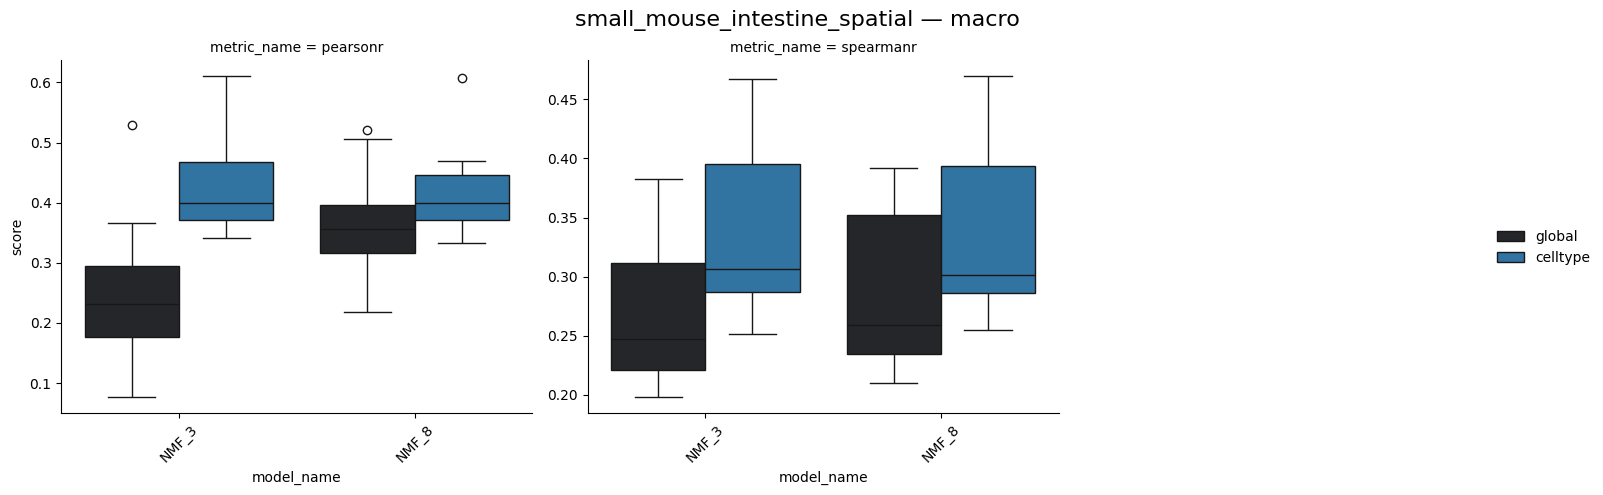

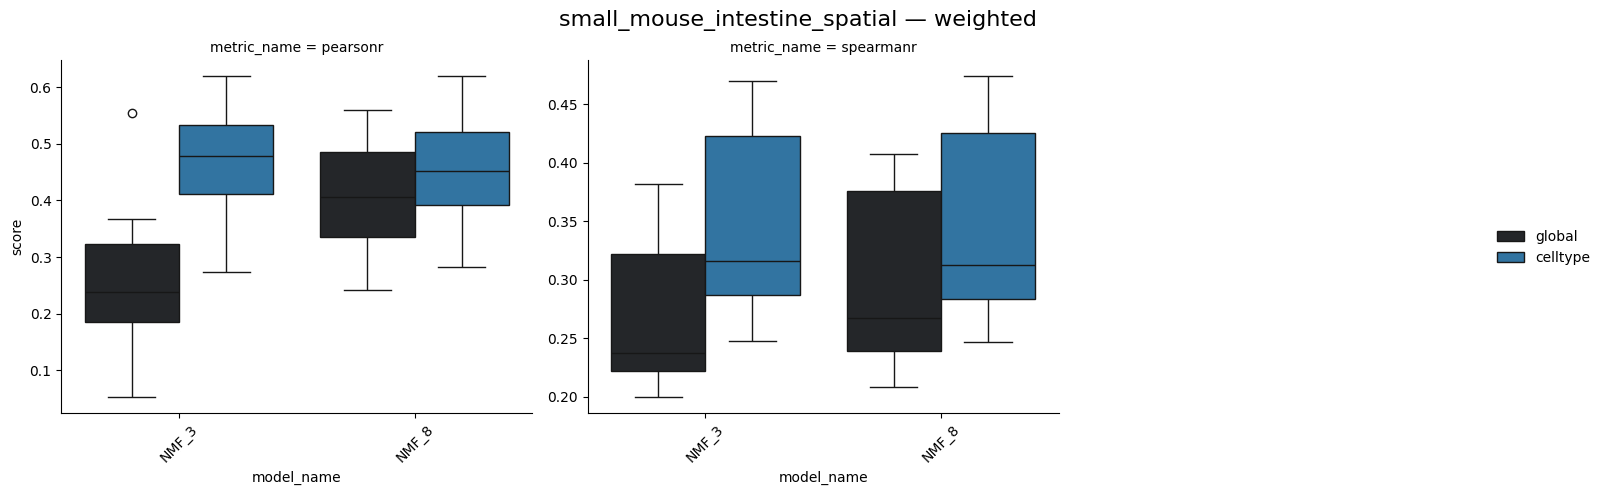

In [70]:
for (
    dataset_name,
    aggregation,
), df_dataset_aggregation in df_prediction_scores.partition_by(
    ["dataset_name", "aggregation"], as_dict=True
).items():
    g = sns.FacetGrid(
        df_dataset_aggregation,
        col="metric_name",
        col_wrap=3,
        height=5,
        sharey=False,
    )
    g.map_dataframe(sns.boxplot, x="model_name", y="score", hue="prediction_scope")
    g.add_legend()
    for ax in g.axes.flatten():
        ax.tick_params(axis="x", rotation=45)
    g.fig.suptitle(f"{dataset_name} — {aggregation}", fontsize=16)
    g.fig.tight_layout()
    g.fig.subplots_adjust(top=0.88)
    plt.show()

In [83]:
result.split_results[0].model_results[0].celltype_results[0].celltype

'BZE'

In [86]:
[metadata.celltype for metadata in result.celltype_metadata]

['BZE',
 'Blood vasc.',
 'Goblet',
 'Lymphatic',
 'MZE',
 'Macrophage',
 'Paneth',
 'Plasma',
 'Rest B',
 'Stem/TA',
 'Stroma',
 'T cell',
 'TZE',
 'Tuft',
 'cDC/monocyte',
 'neurons/enteroendocrine']

In [92]:
[metadata.celltype for metadata in result.split_results[0].model_results[0].celltype_results]

['BZE',
 'Blood vasc.',
 'Goblet',
 'Lymphatic',
 'MZE',
 'Macrophage',
 'Paneth',
 'Plasma',
 'Rest B',
 'Stem/TA',
 'Stroma',
 'T cell',
 'TZE',
 'Tuft',
 'cDC/monocyte',
 'neurons/enteroendocrine']

In [263]:
result = results[0]
result.celltype_metadata

[CelltypeMetadata(celltype='BZE', celltype_mask=cell1       False
 cell2       False
 cell3       False
 cell4       False
 cell5       False
             ...  
 cell8165     True
 cell8166    False
 cell8167    False
 cell8176     True
 cell8198    False
 Name: cluster, Length: 7411, dtype: bool, pca_embedding=array([[-3.1132016 , -1.7622826 ,  0.19408508, ..., -0.00559951,
         -0.08528902,  0.1313281 ],
        [-0.8717437 ,  1.4488981 , -0.5449035 , ...,  0.07624579,
         -0.5653921 , -0.84380037],
        [-2.7146695 , -1.2297726 ,  0.2804047 , ..., -0.00618313,
          0.06186579,  0.14923836],
        ...,
        [-3.2158208 , -2.0440865 ,  0.26817083, ..., -0.2660199 ,
          0.35608122,  0.02828897],
        [-2.0893476 , -2.486663  ,  0.93893206, ..., -0.15161398,
         -0.23263028,  0.9995808 ],
        [-3.1156025 , -1.8686284 ,  0.12321858, ...,  0.4071583 ,
         -0.02706947, -0.27033165]], shape=(1041, 10), dtype=float32), umap_embedding=array([[  2.6

In [97]:
for celltype_metadata, model_celltype_results in zip(result.celltype_metadata, result.split_results[0].model_results[0].celltype_results):
    assert celltype_metadata.celltype == model_celltype_results.celltype


In [317]:
my_iterator = zip(result.celltype_metadata, result.split_results[0].model_results[0].celltype_results)

In [330]:
celltype_metadata, model_celltype_results = next(my_iterator)

In [331]:
from sklearn.cluster import KMeans


celltype_model_latent_dim = model_celltype_results.celltype_model_embedding.shape[1]
celltype_model_clustering = KMeans(n_clusters=celltype_model_latent_dim).fit_predict(celltype_metadata.pca_embedding)
global_model_latent_dim = model_celltype_results.global_model_embedding.shape[1]
global_model_clustering = KMeans(n_clusters=global_model_latent_dim).fit_predict(celltype_metadata.pca_embedding)

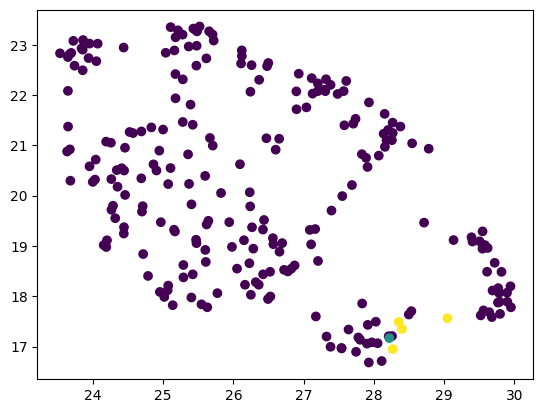

In [332]:
plt.scatter(*celltype_metadata.umap_embedding.T, c=celltype_model_clustering)